In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from src.config import PROCESSED_DATA, CUSTOMER_FEATURES

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [2]:
rfm = pd.read_csv(CUSTOMER_FEATURES)
transactions = pd.read_csv(PROCESSED_DATA, encoding="ISO-8859-1")
rfm.shape, transactions.shape

((5878, 12), (797815, 10))

## Test 1: T-test — Monetary Value (Churned vs Active)

**H0 (null hypothesis):** There is no difference in average monetary value between churned and active customers.
**H1 (alternative):** Churned customers have significantly different average monetary value than active customers.

In [3]:
churned_monetary = rfm[rfm["is_churned"] == 1]["monetary"]
active_monetary = rfm[rfm["is_churned"] == 0]["monetary"]

t_stat, p_value = stats.ttest_ind(churned_monetary, active_monetary, equal_var=False)

print(f"Churned mean monetary: {churned_monetary.mean():.2f}")
print(f"Active mean monetary: {active_monetary.mean():.2f}")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.05:
    print("Result: Statistically significant difference (reject H0)")
else:
    print("Result: No statistically significant difference (fail to reject H0)")

Churned mean monetary: 1134.62
Active mean monetary: 4840.23
T-statistic: -9.7568
P-value: 0.000000
Result: Statistically significant difference (reject H0)


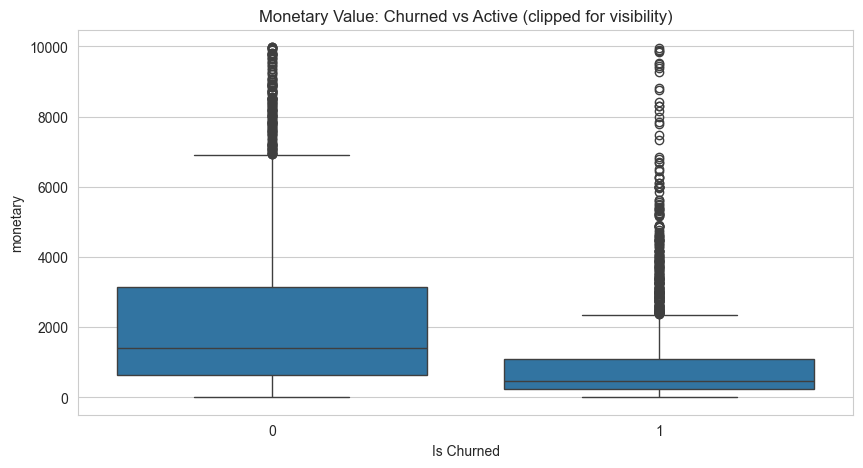

In [4]:
plt.figure()
sns.boxplot(x="is_churned", y="monetary", data=rfm[rfm["monetary"] < 10000])
plt.title("Monetary Value: Churned vs Active (clipped for visibility)")
plt.xlabel("Is Churned")
plt.show()

## Test 2: T-test — Frequency (Churned vs Active)

**H0:** No difference in average order frequency between churned and active customers.
**H1:** Churned customers have significantly different order frequency than active customers.

In [5]:
churned_freq = rfm[rfm["is_churned"] == 1]["frequency"]
active_freq = rfm[rfm["is_churned"] == 0]["frequency"]

t_stat, p_value = stats.ttest_ind(churned_freq, active_freq, equal_var=False)

print(f"Churned mean frequency: {churned_freq.mean():.2f}")
print(f"Active mean frequency: {active_freq.mean():.2f}")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.05:
    print("Result: Statistically significant difference (reject H0)")
else:
    print("Result: No statistically significant difference (fail to reject H0)")

Churned mean frequency: 3.05
Active mean frequency: 9.64
T-statistic: -19.7429
P-value: 0.000000
Result: Statistically significant difference (reject H0)


## Test 3: Chi-square Test — Churn vs Country

**H0:** Churn is independent of customer country.
**H1:** Churn is associated with customer country.

Note: restricted to the top 5 countries by customer count, since very small country
groups produce unreliable chi-square results.

In [6]:
top5_countries = rfm["Country"].value_counts().head(5).index
subset = rfm[rfm["Country"].isin(top5_countries)]

contingency = pd.crosstab(subset["Country"], subset["is_churned"])
print(contingency)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

print(f"\nChi-square statistic: {chi2:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Degrees of freedom: {dof}")

if p_value < 0.05:
    print("Result: Statistically significant association (reject H0)")
else:
    print("Result: No statistically significant association (fail to reject H0)")

is_churned         0     1
Country                   
Belgium           17    11
France            61    34
Germany           69    37
Spain             20    18
United Kingdom  2613  2737

Chi-square statistic: 21.0228
P-value: 0.000313
Degrees of freedom: 4
Result: Statistically significant association (reject H0)


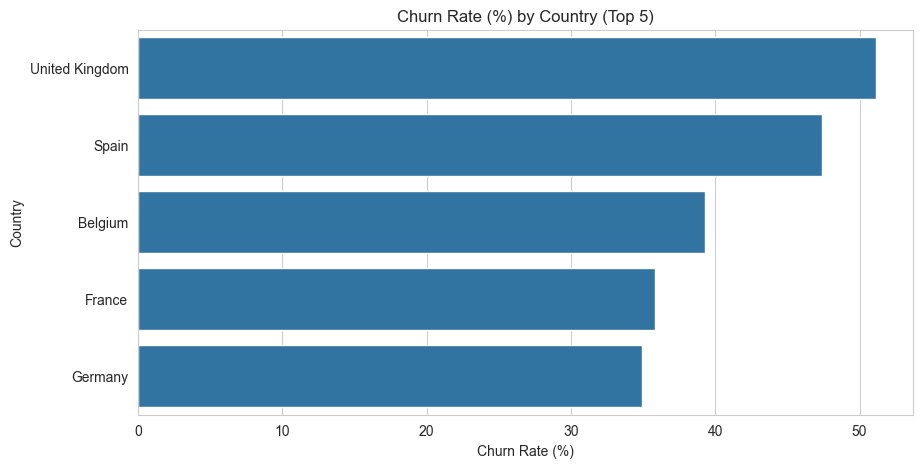

In [7]:
churn_by_country = subset.groupby("Country")["is_churned"].mean().sort_values(ascending=False) * 100

plt.figure()
sns.barplot(x=churn_by_country.values, y=churn_by_country.index)
plt.title("Churn Rate (%) by Country (Top 5)")
plt.xlabel("Churn Rate (%)")
plt.show()

## Test 4: ANOVA — Monetary Value Across Customer Segments

**H0:** Mean monetary value is the same across all RFM segments (Champion, Loyal, At Risk, Lost).
**H1:** At least one segment has a significantly different mean monetary value.

In [8]:
segments = rfm["segment"].unique()
segment_groups = [rfm[rfm["segment"] == seg]["monetary"] for seg in segments]

f_stat, p_value = stats.f_oneway(*segment_groups)

print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.05:
    print("Result: At least one segment differs significantly (reject H0)")
else:
    print("Result: No statistically significant difference across segments (fail to reject H0)")

F-statistic: 110.5155
P-value: 0.000000
Result: At least one segment differs significantly (reject H0)


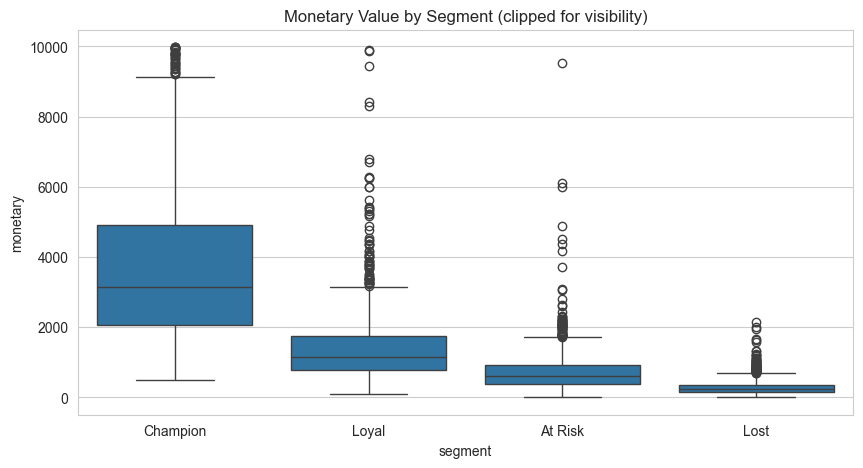

In [9]:
plt.figure()
sns.boxplot(x="segment", y="monetary", data=rfm[rfm["monetary"] < 10000],
            order=["Champion", "Loyal", "At Risk", "Lost"])
plt.title("Monetary Value by Segment (clipped for visibility)")
plt.show()

## Test 5: Pearson Correlation — Recency vs Monetary

Tests whether there's a statistically significant linear relationship between how
recently a customer purchased and how much they've spent overall.

In [10]:
corr_coef, p_value = stats.pearsonr(rfm["recency_days"], rfm["monetary"])

print(f"Correlation coefficient: {corr_coef:.4f}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.05:
    print("Result: Statistically significant correlation (reject H0 of no correlation)")
else:
    print("Result: No statistically significant correlation")

Correlation coefficient: -0.1250
P-value: 0.000000
Result: Statistically significant correlation (reject H0 of no correlation)


## Statistical Testing Summary

| Test | Result | p-value | Interpretation |
|---|---|---|---|
| Monetary: Churned vs Active | Significant | p < 0.000001 | Active customers spend far more on average (£4,840 vs £1,135) — monetary value is a strong churn signal |
| Frequency: Churned vs Active | Significant | p < 0.000001 | Active customers order much more frequently (9.64 vs 3.05 orders) — the strongest behavioral gap observed |
| Churn vs Country (Chi-square) | Significant | p = 0.000313 | Churn rate is associated with country — e.g. Spain shows a notably higher churn rate than the UK or Germany, though sample sizes for non-UK countries are small |
| Monetary across Segments (ANOVA) | Significant | p < 0.000001 | RFM segments (Champion/Loyal/At Risk/Lost) differ meaningfully in spend, validating the segmentation logic |
| Recency vs Monetary (Correlation) | Significant, but weak | p < 0.000001, r = -0.125 | A statistically real but weak negative relationship — customers who purchased more recently tend to spend slightly more, but recency alone is a poor predictor of spend |

**Key takeaway:** Frequency shows the largest relative gap between churned and active customers (9.64 vs 3.05 — roughly 3x), making it likely the single strongest predictor for the churn model, followed closely by monetary value. Country shows a statistically significant association with churn, but the effect size is modest and driven mostly by small non-UK sample sizes, so it's worth including as a feature but not over-weighting in interpretation. The weak recency-monetary correlation (r = -0.125) confirms these are largely independent signals — good news for modeling, since it means R, F, and M each contribute distinct information rather than redundant overlap.